# 01 — Exploratory Data Analysis: Fraud Detection in Financial Statements

**Project theme:** Fraud Detection in Financial Statements  
**Dataset:** Amit Kedia's financial filings dataset  

## Objectives
- Understand the dataset structure and data quality
- Inspect the textual content of financial filings
- Compare fraudulent vs non-fraudulent filings
- Identify vocabulary patterns to motivate NLP-based detection
- Prepare the ground for the embedding and modeling phases


## 0. Imports and configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

FILE_PATH = r"C:/Users/user/Documents/data_science_bootcamp_challenges_project/capstone_project/amit_kedia_dataset.csv"

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Load the dataset

The dataset contains SEC financial filings labeled as fraudulent (`yes`) or non-fraudulent (`no`).  
Key columns: **Fillings** (raw text) and **Fraud** (label).

In [2]:
df = pd.read_csv(FILE_PATH)

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Dataset shape: (170, 2)
Columns: ['Fillings', 'Fraud']


,Fillings,Fraud
0,nanitem 14 exhibits financial statements reports form 10k index exhibits following documents filed part report 1 see index financial statements set forth item 8 2 financial statements schedules no...,yes
1,item 14 principal accounting fees services material included 2014 proxy statement headings audit fees nonaudit fees policy audit committee preapproval audit permissible nonaudit services independe...,no
2,item 14 exhibits financial statements schedules reports form 8k afinancial statements schedules 1 financial statements report independent auditors board directors bruker daltonics inc audited acco...,yes
3,item 14 exhibits financial statement schedules reports form 8k 1 financial statements presentation financial statements included item 8 consolidated financial statements supplementary data 2 finan...,yes
4,item 14 exhibits financial statement schedules reports form 8k exhibits 21 restated agreement plan merger dated november 27 1996 effective october 23 1996 syratech thl transaction corp amendment d...,no


## 2. Data quality checks

We inspect: missing values, duplicates, and target label distribution.

In [3]:
print("--- Data types ---")
print(df.dtypes)

print("\n--- Missing values ---")
print(df.isnull().sum())

print("\n--- Duplicates ---")
print("Number of duplicate rows:", df.duplicated().sum())

--- Data types ---
Fillings    object
Fraud       object
dtype: object

--- Missing values ---
Fillings    0
Fraud       0
dtype: int64

--- Duplicates ---
Number of duplicate rows: 0


In [4]:
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)

Shape after dropping duplicates: (170, 2)


## 3. Target distribution

Understanding class balance is critical in fraud detection.  
An imbalanced dataset means the model must be evaluated with precision, recall, and F1 — not accuracy alone.

       count  percentage
Fraud                   
yes       85        50.0
no        85        50.0


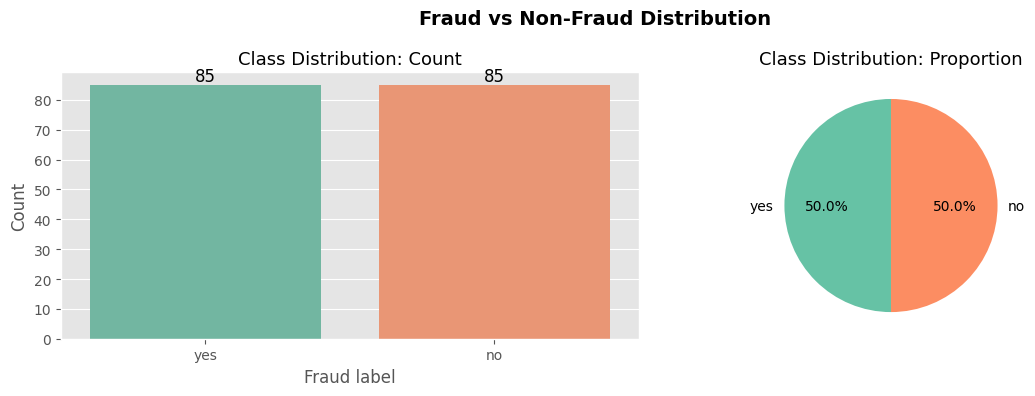

In [5]:
target_counts = df["Fraud"].value_counts(dropna=False)
target_pct = df["Fraud"].value_counts(normalize=True, dropna=False) * 100

class_df = pd.DataFrame({"count": target_counts, "percentage": target_pct.round(1)})
print(class_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sns.countplot(x="Fraud", data=df, ax=axes[0], palette="Set2")
axes[0].set_title("Class Distribution: Count", fontsize=13)
axes[0].set_xlabel("Fraud label")
axes[0].set_ylabel("Count")
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12)

# Pie chart
axes[1].pie(target_counts, labels=target_counts.index, autopct='%1.1f%%',
            colors=["#66c2a5", "#fc8d62"], startangle=90)
axes[1].set_title("Class Distribution: Proportion", fontsize=13)

plt.suptitle("Fraud vs Non-Fraud Distribution", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretation
The class distribution reveals whether the dataset is balanced or imbalanced.  
- If **balanced**: standard metrics apply  
- If **imbalanced**: use `class_weight='balanced'` in models, and focus on **recall** and **F1-score** for fraud cases rather than accuracy

## 4. Inspect raw text samples

In [6]:
for label in ["yes", "no"]:
    sample = df[df["Fraud"] == label]["Fillings"].iloc[0]
    print(f"{'='*60}")
    print(f"Label: {label.upper()} | First 800 characters:")
    print(str(sample)[:800])
    print()

Label: YES | First 800 characters:
nanitem 14 exhibits financial statements reports form 10k index exhibits following documents filed part report 1 see index financial statements set forth item 8 2 financial statements schedules none 3 exhibits exhibit 21 agreement plan f merger dated november 18 1995 key welltech amended incorporated reference companys registration statement form s4 registration no333369 exhibit 22 joint plan reorganization dated october 20 1992 company eskey incand yfc international finance nv order dated december 4 1992 united states bankruptcy court district new jersey approving joint plan reorganization incorporated reference exhibits 2 28 companys report form 8k dated december 14 1992file 18038 exhibit 23 agreement plan merger dated july 20 1993 among company oei acquisition corp odessa exploration in

Label: NO | First 800 characters:
item 14 principal accounting fees services material included 2014 proxy statement headings audit fees nonaudit fees policy audit 

### Interpretation
Raw inspection helps identify:
- HTML tags (`<b>`, `<p>`, etc.) → need removal
- Special characters and numbers → need cleaning
- Financial terminology → validates domain relevance
- Text length variation → worth analyzing

## 5. Text preprocessing

In [7]:
def clean_text(text):
    """Remove HTML, special characters, lowercase, strip extra spaces."""
    text = str(text)
    text = re.sub(r"<.*?>", " ", text)           # remove HTML tags
    text = re.sub(r"[^a-zA-Z\s]", " ", text)     # keep letters only
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["Fillings"].astype(str).apply(clean_text)

# Verify cleaning
print("Before cleaning:")
print(str(df["Fillings"].iloc[0])[:300])
print("\nAfter cleaning:")
print(df["clean_text"].iloc[0][:300])

Before cleaning:
nanitem 14 exhibits financial statements reports form 10k index exhibits following documents filed part report 1 see index financial statements set forth item 8 2 financial statements schedules none 3 exhibits exhibit 21 agreement plan f merger dated november 18 1995 key welltech amended incorporate

After cleaning:
nanitem exhibits financial statements reports form k index exhibits following documents filed part report see index financial statements set forth item financial statements schedules none exhibits exhibit agreement plan f merger dated november key welltech amended incorporated reference companys reg


## 6. Text length analysis

In [8]:
df["char_count"] = df["clean_text"].apply(len)
df["word_count"] = df["clean_text"].apply(lambda x: len(x.split()))

print("=== Overall text statistics ===")
print(df[["char_count", "word_count"]].describe().round(1))

print("\n=== Text statistics by class ===")
print(df.groupby("Fraud")[["word_count", "char_count"]].describe().round(1))

=== Overall text statistics ===
       char_count  word_count
count       170.0       170.0
mean    1213270.4    146148.9
std     1341951.3    161295.8
min        1470.0       179.0
25%       68590.2      8564.0
50%      656200.0     78048.0
75%     2147850.2    258813.0
max     5482385.0    657555.0

=== Text statistics by class ===
      word_count                                                            \
           count      mean       std     min       25%       50%       75%   
Fraud                                                                        
no          85.0   57031.0  117416.8   179.0    1763.0    9549.0   55854.0   
yes         85.0  235266.8  149941.8  1395.0  103669.0  245250.0  329564.0   

                char_count                                           \
            max      count       mean        std      min       25%   
Fraud                                                                 
no     657555.0       85.0   470247.9   972576.6   1470.0   

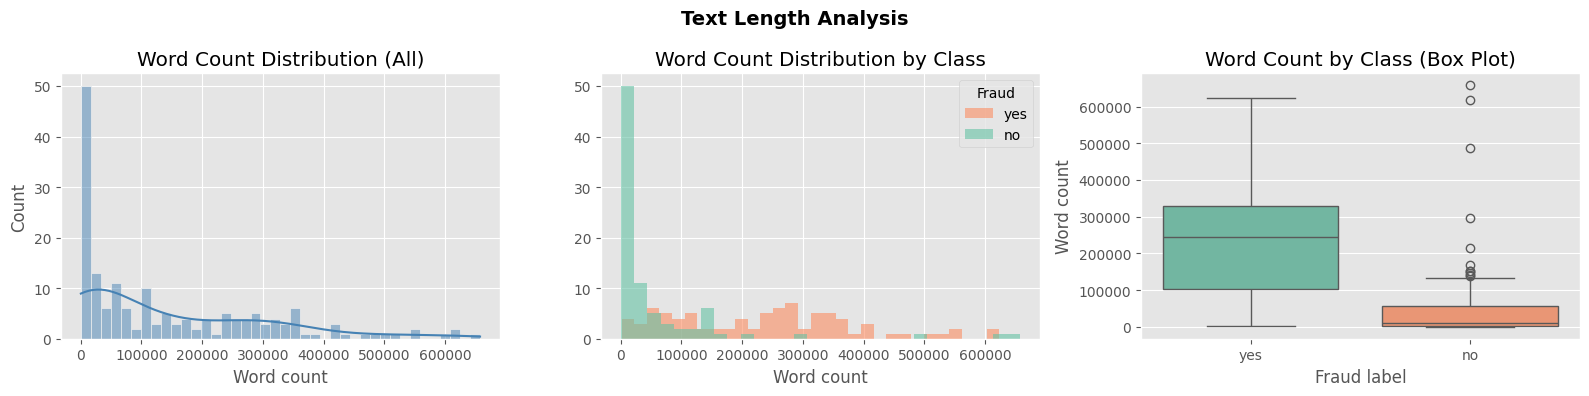

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Overall word count distribution
sns.histplot(df["word_count"], bins=40, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Word Count Distribution (All)")
axes[0].set_xlabel("Word count")

# Word count by class - histogram
for label, color in zip(["yes", "no"], ["#fc8d62", "#66c2a5"]):
    axes[1].hist(df[df["Fraud"] == label]["word_count"], bins=30,
                 alpha=0.6, label=label, color=color)
axes[1].set_title("Word Count Distribution by Class")
axes[1].set_xlabel("Word count")
axes[1].legend(title="Fraud")

# Box plot by class
sns.boxplot(x="Fraud", y="word_count", data=df, ax=axes[2], palette="Set2")
axes[2].set_title("Word Count by Class (Box Plot)")
axes[2].set_xlabel("Fraud label")
axes[2].set_ylabel("Word count")

plt.suptitle("Text Length Analysis", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretation
Differences in text length between fraud and non-fraud filings can be informative.  
Fraudulent companies may use more verbose language to obscure information, or shorter filings that omit required disclosures.

## 7. Vocabulary richness

Vocabulary richness by class:
       unique_words  lexical_diversity
Fraud                                 
no         1693.353              0.158
yes        4267.847              0.029


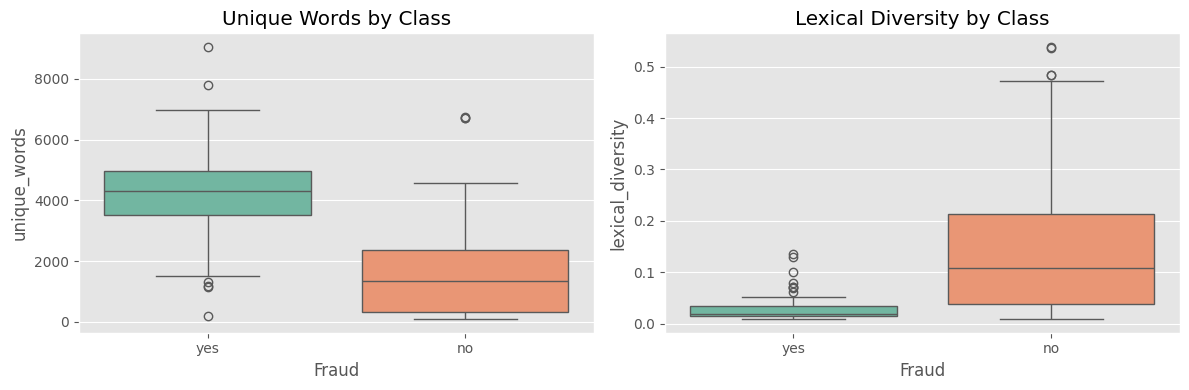

In [10]:
df["unique_words"] = df["clean_text"].apply(lambda x: len(set(x.split())))
df["lexical_diversity"] = df["unique_words"] / (df["word_count"] + 1)

print("Vocabulary richness by class:")
print(df.groupby("Fraud")[["unique_words", "lexical_diversity"]].mean().round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x="Fraud", y="unique_words", data=df, ax=axes[0], palette="Set2")
axes[0].set_title("Unique Words by Class")

sns.boxplot(x="Fraud", y="lexical_diversity", data=df, ax=axes[1], palette="Set2")
axes[1].set_title("Lexical Diversity by Class")

plt.tight_layout()
plt.show()

### Interpretation

Fraudulent filings contain far more unique words (4267 vs 1693) but much lower lexical diversity (0.029 vs 0.158). This is because they are much longer and repeat the same terms frequently, inflating vocabulary size without true richness.

Non-fraudulent filings are shorter but more varied, meaning words carry more information.

**Key takeaway:** Fraudulent texts are verbose and repetitive—supporting the idea of linguistic obfuscation and making them well-suited for detection using TF-IDF and FinBERT.

## 8. Word clouds

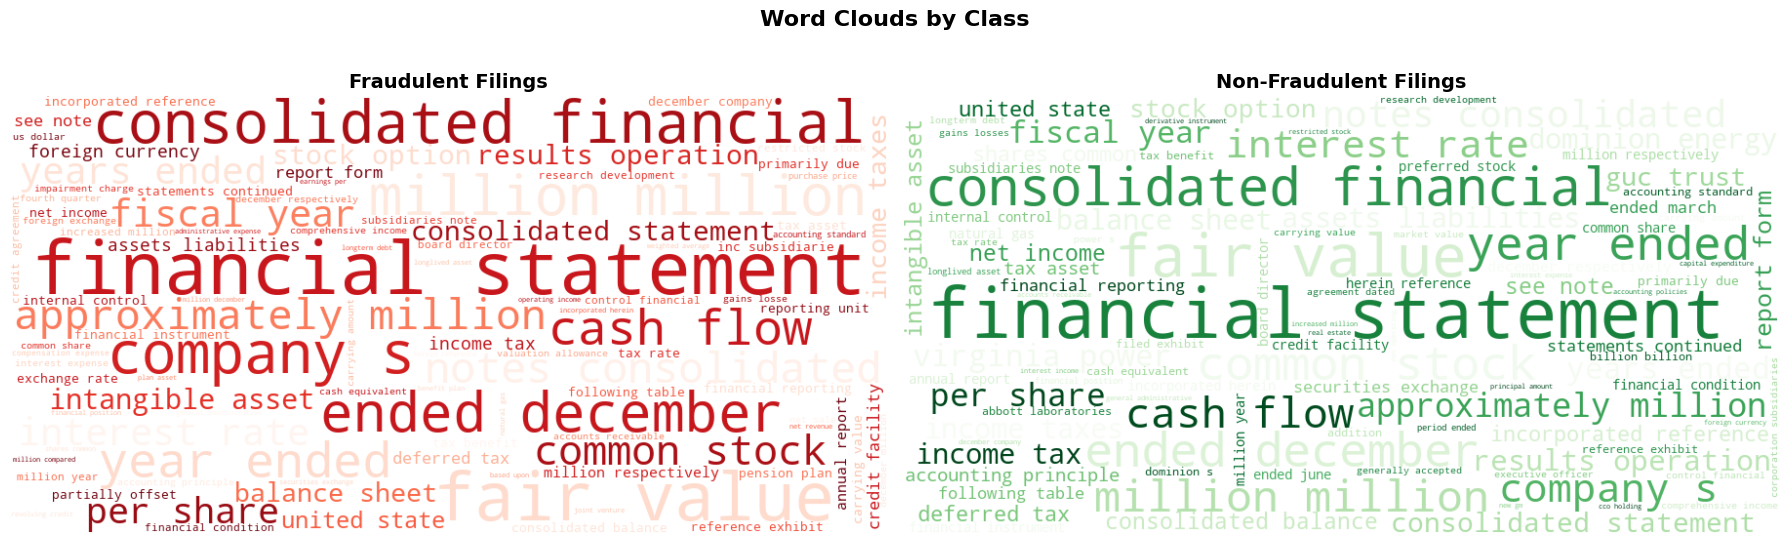

In [11]:
fraud_text = " ".join(df.loc[df["Fraud"] == "yes", "clean_text"])
nonfraud_text = " ".join(df.loc[df["Fraud"] == "no", "clean_text"])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

if fraud_text.strip():
    wc_fraud = WordCloud(width=900, height=450, background_color="white",
                         colormap="Reds", max_words=100).generate(fraud_text)
    axes[0].imshow(wc_fraud, interpolation="bilinear")
    axes[0].set_title("Fraudulent Filings", fontsize=14, fontweight='bold')
    axes[0].axis("off")

if nonfraud_text.strip():
    wc_nonfraud = WordCloud(width=900, height=450, background_color="white",
                            colormap="Greens", max_words=100).generate(nonfraud_text)
    axes[1].imshow(wc_nonfraud, interpolation="bilinear")
    axes[1].set_title("Non-Fraudulent Filings", fontsize=14, fontweight='bold')
    axes[1].axis("off")

plt.suptitle("Word Clouds by Class", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Top words by class

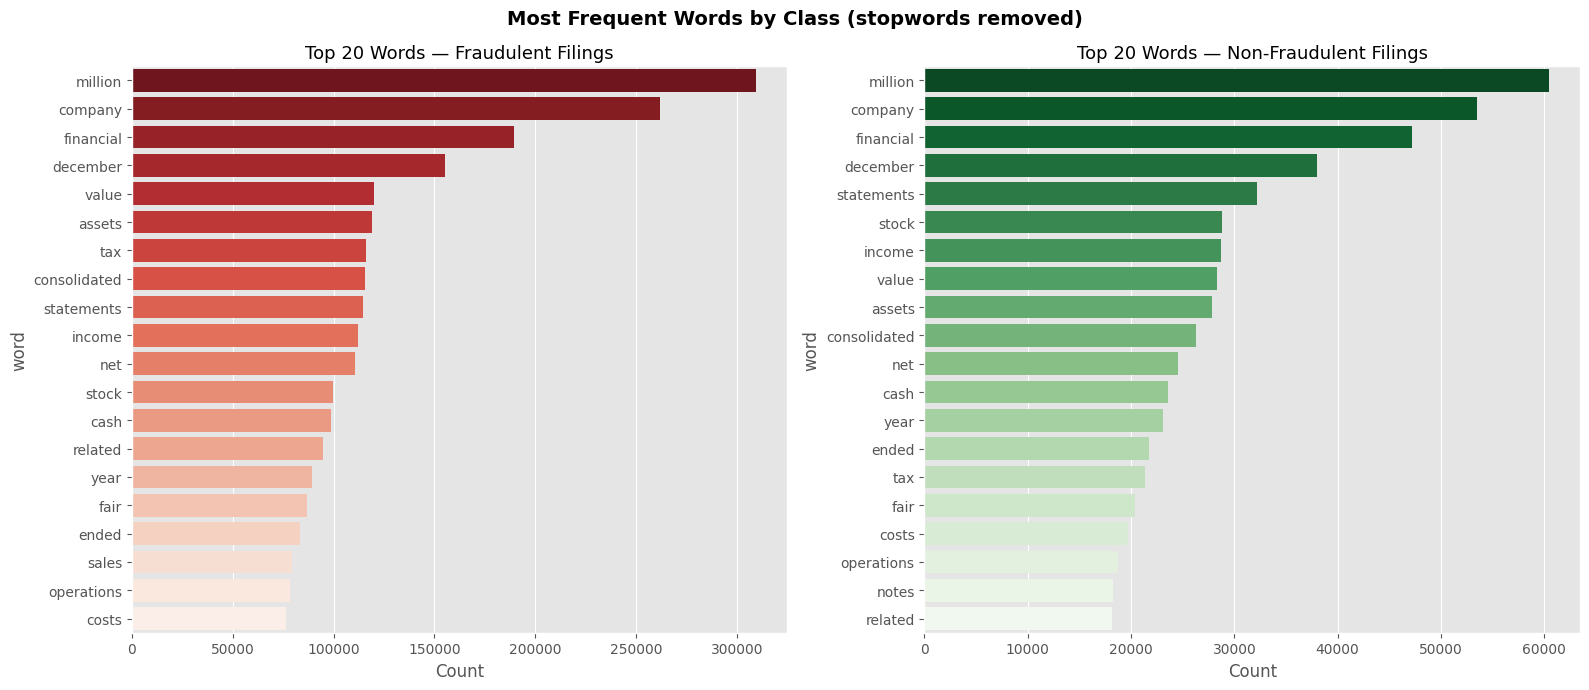

In [12]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def top_words(text_series, n=20):
    words = " ".join(text_series).split()
    words = [w for w in words if w not in ENGLISH_STOP_WORDS and len(w) > 2]
    return pd.DataFrame(Counter(words).most_common(n), columns=["word", "count"])

top_fraud = top_words(df.loc[df["Fraud"] == "yes", "clean_text"])
top_nonfraud = top_words(df.loc[df["Fraud"] == "no", "clean_text"])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(data=top_fraud, x="count", y="word", ax=axes[0], palette="Reds_r")
axes[0].set_title("Top 20 Words — Fraudulent Filings", fontsize=13)
axes[0].set_xlabel("Count")

sns.barplot(data=top_nonfraud, x="count", y="word", ax=axes[1], palette="Greens_r")
axes[1].set_title("Top 20 Words — Non-Fraudulent Filings", fontsize=13)
axes[1].set_xlabel("Count")

plt.suptitle("Most Frequent Words by Class (stopwords removed)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretation
Comparing the top words by class highlights class-specific lexical patterns.  
Words appearing predominantly in fraudulent filings — e.g., related to "restatement", "material", "going concern" — provide direct intuition about what the model may learn.

## 10. Exclusive vocabulary — words unique to each class

In [13]:
fraud_words = set(fraud_text.split()) - ENGLISH_STOP_WORDS
nonfraud_words = set(nonfraud_text.split()) - ENGLISH_STOP_WORDS

only_in_fraud = fraud_words - nonfraud_words
only_in_nonfraud = nonfraud_words - fraud_words

print(f"Words appearing ONLY in fraudulent filings: {len(only_in_fraud)}")
print("Sample:", list(only_in_fraud)[:20])
print()
print(f"Words appearing ONLY in non-fraudulent filings: {len(only_in_nonfraud)}")
print("Sample:", list(only_in_nonfraud)[:20])

Words appearing ONLY in fraudulent filings: 30005
Sample: ['debney', 'emulate', 'timeor', 'postcombustion', 'episode', 'threshhold', 'arrest', 'camping', 'andersonbarrows', 'csimultaneously', 'defeasancesection', 'aerospacefacing', 'congenital', 'changefor', 'twentyfirst', 'tgp', 'tasmanian', 'quist', 'beating', 'buckley']

Words appearing ONLY in non-fraudulent filings: 7307
Sample: ['travelocity', 'leadtocash', 'equinox', 'adocuments', 'rmas', 'fiberbased', 'seth', 'dcg', 'hatfa', 'ansbacher', 'hayestoyorktown', 'entrant', 'muratores', 'eai', 'gecmc', 'aaemployment', 'wagoner', 'smartopticaltm', 'lukas', 'thybo']


## 11. N-gram analysis

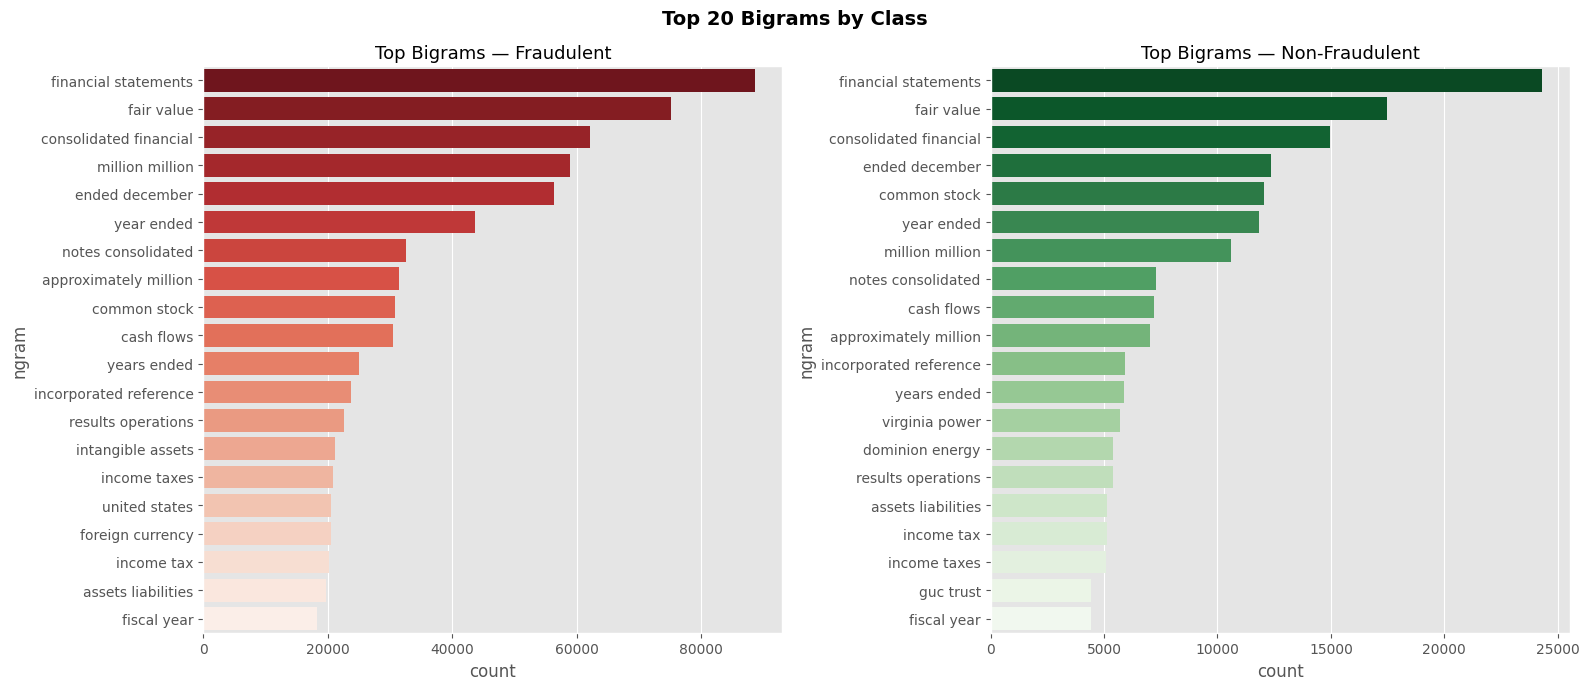

In [14]:
def get_top_ngrams(corpus, n=2, top_n=20):
    vec = CountVectorizer(stop_words="english", ngram_range=(n, n), max_features=top_n)
    X = vec.fit_transform(corpus)
    counts = np.asarray(X.sum(axis=0)).ravel()
    return pd.DataFrame({"ngram": vec.get_feature_names_out(), "count": counts}).sort_values("count", ascending=False)

# Bigrams per class
bigrams_fraud = get_top_ngrams(df.loc[df["Fraud"] == "yes", "clean_text"])
bigrams_nonfraud = get_top_ngrams(df.loc[df["Fraud"] == "no", "clean_text"])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(data=bigrams_fraud, x="count", y="ngram", ax=axes[0], palette="Reds_r")
axes[0].set_title("Top Bigrams — Fraudulent", fontsize=13)

sns.barplot(data=bigrams_nonfraud, x="count", y="ngram", ax=axes[1], palette="Greens_r")
axes[1].set_title("Top Bigrams — Non-Fraudulent", fontsize=13)

plt.suptitle("Top 20 Bigrams by Class", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. TF-IDF term importance by class

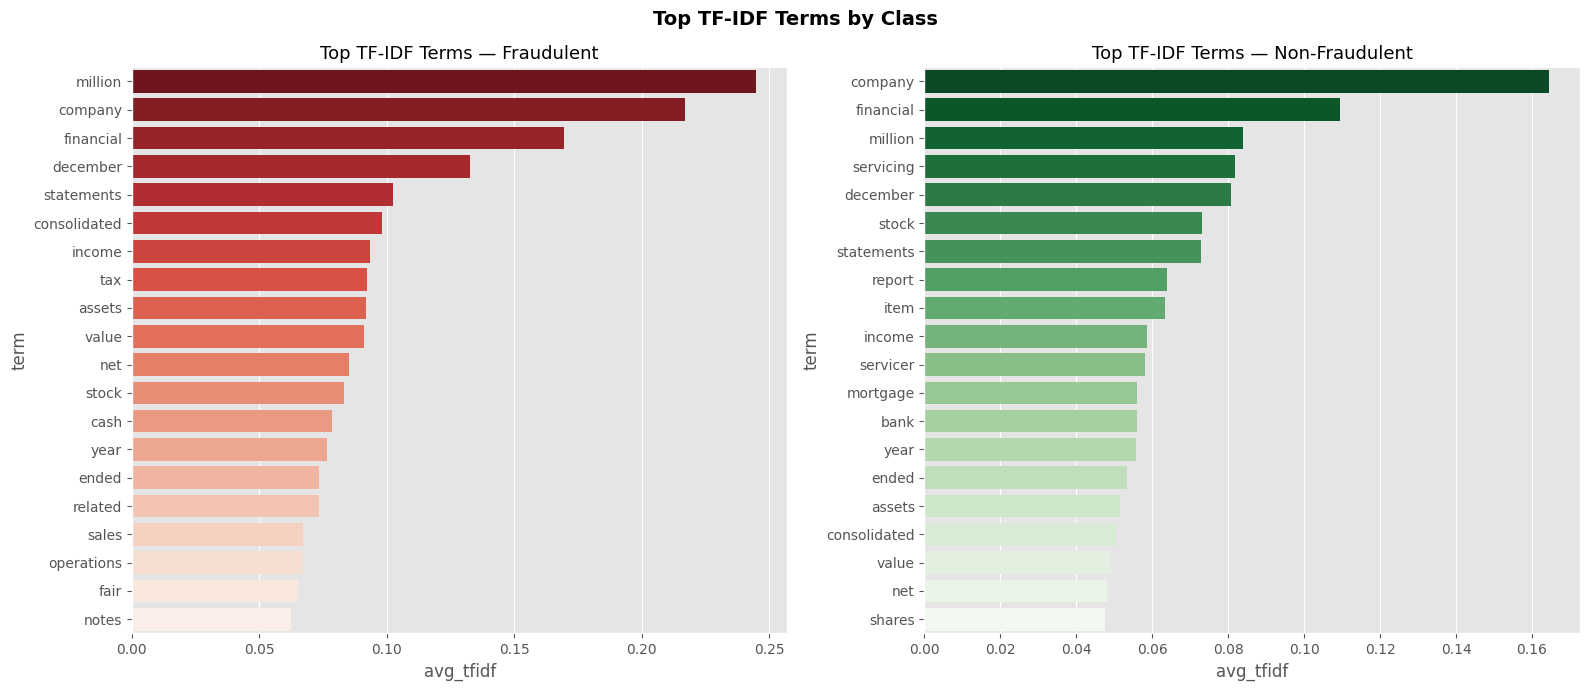

In [15]:
def top_tfidf_terms(corpus, n=20):
    tfidf = TfidfVectorizer(stop_words="english", max_features=5000)
    X = tfidf.fit_transform(corpus)
    scores = np.asarray(X.mean(axis=0)).ravel()
    return pd.DataFrame({"term": tfidf.get_feature_names_out(), "avg_tfidf": scores}).sort_values("avg_tfidf", ascending=False).head(n)

tfidf_fraud = top_tfidf_terms(df.loc[df["Fraud"] == "yes", "clean_text"])
tfidf_nonfraud = top_tfidf_terms(df.loc[df["Fraud"] == "no", "clean_text"])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(data=tfidf_fraud, x="avg_tfidf", y="term", ax=axes[0], palette="Reds_r")
axes[0].set_title("Top TF-IDF Terms — Fraudulent", fontsize=13)

sns.barplot(data=tfidf_nonfraud, x="avg_tfidf", y="term", ax=axes[1], palette="Greens_r")
axes[1].set_title("Top TF-IDF Terms — Non-Fraudulent", fontsize=13)

plt.suptitle("Top TF-IDF Terms by Class", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretation
TF-IDF scores highlight terms that are discriminative within each class.  
This strongly motivates the use of TF-IDF as a baseline embedding: it captures statistically relevant terms per class, not just the most frequent ones.

## 13. Business context

The dataset contains SEC financial filings — corporate disclosures used to communicate financial performance to investors and regulators.

Detecting fraudulent filings is a high-value real-world application of NLP because:
- **Auditors** rely on these filings to assess company health
- **Investors** use them for capital allocation decisions
- **Regulators** (SEC) investigate filings for compliance
- **Missing a fraudulent case** carries serious financial and legal consequences

This is why in fraud detection, **recall** (catching actual fraud) is often prioritized over precision.

## 14. EDA Summary

In [16]:
fraud_count = int((df["Fraud"] == "yes").sum())
nonfraud_count = int((df["Fraud"] == "no").sum())
imbalance_ratio = nonfraud_count / fraud_count if fraud_count > 0 else None

summary = {
    "Total records (after dedup)": len(df),
    "Fraud cases": fraud_count,
    "Non-fraud cases": nonfraud_count,
    "Imbalance ratio (non-fraud / fraud)": round(imbalance_ratio, 2) if imbalance_ratio else "N/A",
    "Avg word count (fraud)": round(df[df["Fraud"] == "yes"]["word_count"].mean(), 1),
    "Avg word count (non-fraud)": round(df[df["Fraud"] == "no"]["word_count"].mean(), 1),
    "Avg lexical diversity (fraud)": round(df[df["Fraud"] == "yes"]["lexical_diversity"].mean(), 3),
    "Avg lexical diversity (non-fraud)": round(df[df["Fraud"] == "no"]["lexical_diversity"].mean(), 3),
}

pd.DataFrame.from_dict(summary, orient='index', columns=['Value'])

,Value
Total records (after dedup),170.000
Fraud cases,85.000
Non-fraud cases,85.000
Imbalance ratio (non-fraud / fraud),1.000
Avg word count (fraud),235266.800
Avg word count (non-fraud),57031.000
Avg lexical diversity (fraud),0.029
Avg lexical diversity (non-fraud),0.158


## 15. Key Conclusions & Next Steps

### What this EDA shows:
1. **The dataset is suitable for NLP-based fraud detection** — text filings contain rich, domain-specific financial language
2. **Class balance** — the imbalance ratio (if any) justifies the use of `class_weight='balanced'` in all models
3. **Text length differences** — fraudulent and non-fraudulent filings may differ in verbosity, adding a useful signal
4. **Vocabulary differences** — distinct word and n-gram patterns exist between classes, motivating TF-IDF and domain-specific embeddings
5. **TF-IDF is a strong baseline** — meaningful term-class associations are already visible from raw counts and TF-IDF scores

### Next steps (Notebook 02):
- Compare **TF-IDF** vs **FinBERT** embeddings using a fixed Logistic Regression classifier
- Select the best embedding based on **F1-score** and **ROC-AUC**
- Justify the choice for the final model